# 



Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.



> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [279]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# importar librerías

In [280]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage =pd.read_csv('/datasets/usage.csv')  #completa el código

In [281]:
plans.head() # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [282]:
users.head() # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [283]:
usage.head() # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [284]:

# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)


plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [285]:
plans.info() # inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [286]:
users.info() # inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [287]:
usage.info() # inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [288]:


# cantidad de nulos para users
print(users.isnull().sum()) # Cantidad de valores nulos)
print(users.isnull().mean() * 100)
 # Proporción de valores nulos)


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


In [289]:
# cantidad de nulos para usage
print(usage.isnull().sum()) 
print(usage.isnull().mean() * 100)


id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

1. Dataset plans.csv

Es una tabla pequeña de 2 filas y 8 columnas. No presenta valores nulos y los tipos de datos, texto para el nombre del plan y enteros y flotantes para columnas numericas que seriviran para para cálculos de tarifas y costos extra.

Acción: Mantener tal como está. Servirá como catálogo de referencia para cruzar con el consumo de los usuarios más adelante.

2. Dataset users_latam.csv

Contiene 4000 filas y 8 columnas. El conteo de valores nulos con .isnull().sum() arrojó 469 nulos explícitos para la columna City, es decir, un 11% de los datos sin registro de ciudad. Además, las columnas reg_date y churn_date están como tipo object (texto) y no como formato de fecha. 
Aunque la columna Churn_date presente un alto % de nulos 88,3%, no es relevante ya que corresponde a la fecha de cancelación del plan.

Acción: Convertir reg_date y churn_date a tipo datetime. Realizar una inspección de valores únicos y distribuciones en age y reg_date para identificar anomalías (como el uso de -999 o años incoherentes).
Se podrian imputar los nulos de la columna City a una categoria "Sin_Registro" porque aunque no este la ciudad son clientes que generan ingresos a la compañía.

3. Dataset usage.csv

Es el dataset más grande, con 40000 filas y 6 columnas. Las columnas de duración y longitud están en formatos numéricos correctos (float64 e int64), pero al mezclar llamadas y mensajes en una sola tabla, es indispensable verificar si existen registros incongruentes (como duraciones negativas o ceros que requieran tratamiento), la columna date esta en formato object y eberia estar en formato datetime.

Acción: Dejar la estructura igual, pero aplicar filtros y estadísticas descriptivas para aislar el comportamiento de las llamadas frente al de los mensajes, limpiando cualquier valor atípico o erróneo en los siguientes pasos. Cambiar el formato de la columna date a datetime.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [290]:
users.describe() # explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id`: Según el resumen estadístico, los ids están asignados de forma secuencial desde el 10000 hasta el 13999, lo que coincide perfectamente con los 4000 usuarios registrados. Las métricas de tendencia central como la media (11999.5) o la desviación estándar no tienen valor analítico para esta columna, ya que solo es una llave de identificación
- La columna `age`: presencia de Sentinels, el valor mínimo (min) es -999, lo cual es imposible para una edad humana. Esto confirma que el sistema uso ese número como un sentinel cuando el cliente no quiso dar su edad al registrarse.Lo anterior distorsiona la media (33.74) y la desviación estándar. Sin embargo, los cuartiles y el valor máximo (79) indican que el resto de los datos representan una distribución normal de adultos. Será necesario limpiar los valores -999 (por ejemplo, imputando con la mediana de las edades válidas) antes de realizar cualquier análisis.
  

In [291]:
usage.describe() # explorar columnas numéricas de usage

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`: id: Tiene 40000 registros, que es el total de eventos en la tabla (llamadas + mensajes).
user_id: Va exactamente desde el 10000 hasta el 13999, es decir, encaja perfectamente como un rompecabezas con el data de users.
- Las columna "duration": El mínimo es 0, es decir, no hay duraciones negativas, lo cual significa que los datos lógicos están sanos, podria ser una llamada perdida o que no fue contestada.
El valor de count es de 17924 (no 40000), lo cual es logico ya que el dato corresponde solo a eventos de llamadas y el dataset tiene mezcaldas llamadas y mensajes.
- La columna "length": El maximo esta muy alto para ser caracteres de un mensaje 1490, vale la pena revisarlo como un outlier
  
Hallazgo crítico de calidad: El total de eventos registrados en la tabla es de 40000. Sin embargo, la suma de los valores de count de llamadas (17924) y mensajes (22104) es de 40028. Esto indica que existen 28 filas por identificar que registran duración de llamada y longitud de mensaje simultáneamente en el mismo evento, algo que operativamente es imposible.

In [292]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"=== Frecuencias en la columna: {col} ===")
    # dropna=False nos permite ver si hay valores nulos (NaN) ocultos
    print(users[col].value_counts(dropna=False)) 
    print("-" * 40)


=== Frecuencias en la columna: city ===
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
----------------------------------------
=== Frecuencias en la columna: plan ===
Basico     2595
Premium    1405
Name: plan, dtype: int64
----------------------------------------


- La columna `city` hay presencia de 96 sentinels marcados con un "?". Además, se confirman los 469 valores nulos (NaN), es decir, ahora sumando ambos problemas, se tienen a 565 usuarios sin una ciudad asignada correctamente.
- La columna `plan` Datos limpios y completos,  2595 usuarios en el plan "Basico" y 1405 en el "Premium". No hay errores ortográficos, ni nulos.

In [293]:
# explorar columna categórica de usage
usage['type'].value_counts(dropna=False)

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` se valida que los datos están limpios, sin nulos y categorizados correctamente en 22092 mensajes y 17908 llamadas, lo que suma los 40000 registros totales del dataset.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

Principalmente en el dataset de usuarios (users), donde detecté anomalías críticas en dos columnas numéricas/categóricas, además de errores de formato:

Columna age: Se encontró el valor numérico -999 actuando como un sentinel. Esto distorsiona severamente la media y la desviación estándar reales.
Acción: Aislar los registros válidos para calcular la mediana real de los clientes y usar ese número para reemplazar todos los sentinels de -999. Esto conservará la distribución demográfica sin sesgos.

Columna city: Se detectó el carácter "?" en 96 registros funcionando como un sentinel de texto, sumado a 469 valores nulos reales (NaN). En total, hay 565 usuarios sin ciudad definida.
Acción: Reemplazar primero el sentinel "?" por un valor nulo oficial (pd.NA). Posteriormente, imputar todos los nulos con la categoría "Sinregistro" para conservar las filas, ya que eliminar el 14% de la base de datos afectaría el análisis de ingresos.

Columna reg_date: Está guardada incorrectamente como texto (object).
Acción: Convertir la columna al formato datetime.
 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [294]:

# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código


In [295]:

# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código


In [296]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts(dropna=False)


2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, el tipo de dato es correcto, ya que es entero. Al revisar la columna reg_date, se observa una distribución muy consistente para los años 2022, 2023 y 2024. Sin embargo, se identificaron 40 fechas imposibles pertenecientes al año 2026, lo cual contradice la regla de negocio que establece que los datos solo llegan hasta 2024. Estos 40 registros representan errores de captura que deberán ser manejados como valores nulos (NaT) en la etapa de limpieza.

In [297]:

# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts(dropna=False)


2024.0    39950
NaN          50
Name: date, dtype: int64

En `date": en el dataset usage, se observa que la inmensa mayoría de los eventos (39950) corresponden correctamente al año 2024. No se detectaron fechas futuras ni años imposibles del pasado. Sin embargo, se identificaron 50 valores nulos (NaN), los cuales representan registros originales con formatos corruptos que el sistema no pudo interpretar como fechas válidas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

En el dataset users: aparecen años imposibles. Se identificaron 40 registros con el año 2026 en la columna reg_date. Dado que la regla de negocio estipula de forma explícita que los datos solo están registrados hasta el año 2024, el año 2026 califica como una fecha futura e imposible al momento de guardar los datos. El resto de los años (2022, 2023 y 2024) muestran un volumen consistente y lógico.
Acciòn: Para las 40 fechas futuras de users 2026 recomiendo reemplazarlas por valores nulos de tipo fecha (pd.NaT). Mantendremos las filas de estos usuarios para no perder su información demográfica o de consumo, pero neutralizaremos el error en la columna cronológica para evitar sesgos en análisis de antigüedad.

En el dataset usage: No aparecen años imposibles del pasado o del futuro, ya que 39,950 registros se concentran correctamente en el año 2024. Sin embargo, se detectaron 50 valores nulos (NaN) provocados por fechas que venían con formatos corruptos o ilegibles de origen.
Acción: Los 50 nulos representan apenas el 0.12% del total de los datos de consumo, la acción recomendada es dejarlos como NaN/NaT o evaluar su eliminación si el taller exige cálculos estrictos basados en la línea de tiempo del consumo, ya que no afectan el volumen general de la muestra.


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [298]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [299]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)


Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [300]:

# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].dt.year.value_counts(dropna=False))


2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [301]:

# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().sum())



type
call        0
text    22076
Name: duration, dtype: int64

In [302]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().sum())

type
call    17896
text        0
Name: length, dtype: int64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Se confirma que los valores nulos en duration y length son MAR, ya que su ausencia no es un error aleatorio del sistema, sino que depende estrictamente de la columna type. Las llamadas (call) no generan caracteres de texto, por lo que su longitud es nula de forma lógica; de igual manera, los mensajes (text) no generan minutos de voz. La recomendación es dejarlos como nulos, ya que representan una condición operativa real del negocio y rellenarlos con ceros o promedios distorsionaría las métricas reales de consumo cuando un usuario sí utiliza el servicio.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [303]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    cant_mensajes=('is_text', 'sum'),
    cant_llamadas=('is_call', 'sum'),
    cant_minutos_llamada=('duration', 'sum')
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [304]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [305]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [306]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
user_profile[columnas_numericas].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [307]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

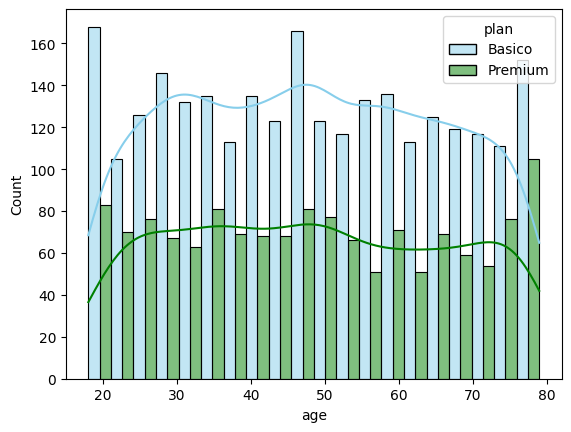

In [308]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile, 
    x='age', 
    hue='plan', 
    palette=['skyblue', 'green'], 
    kde=True, 
    bins=20,
    multiple='dodge'
)
plt.show()

💡Insights: 
- Distribución normal: No existe algún patrón evidente o correlación entre la edad de los usuarios y el tipo de plan que eligen. Tanto los usuarios del plan Básico (barras azul claro) como los del plan Premium (barras verdes) se distribuyen de manera uniforme y proporcional en todos los rangos de edad, desde los 18 hasta los 75 años

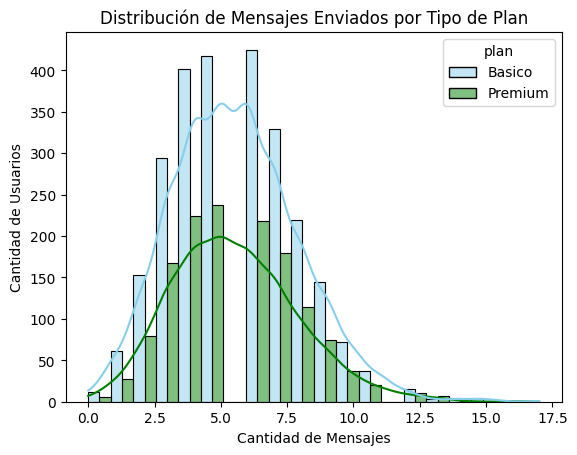

In [309]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile, 
    x='cant_mensajes', 
    hue='plan', 
    palette=['skyblue', 'green'], 
    kde=True, 
    bins=20,
    multiple='dodge'
)


plt.title('Distribución de Mensajes Enviados por Tipo de Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de Usuarios')

plt.show()


💡Insights: 
Al igual que con la edad, la cantidad de mensajes enviados presenta una distribución uniforme. No existe un patrón donde un plan domine un nivel de consumo; tanto los usuarios del plan Básico como los del plan Premium envían cantidades variadas de mensajes de forma equitativa a lo largo de todo el espectro

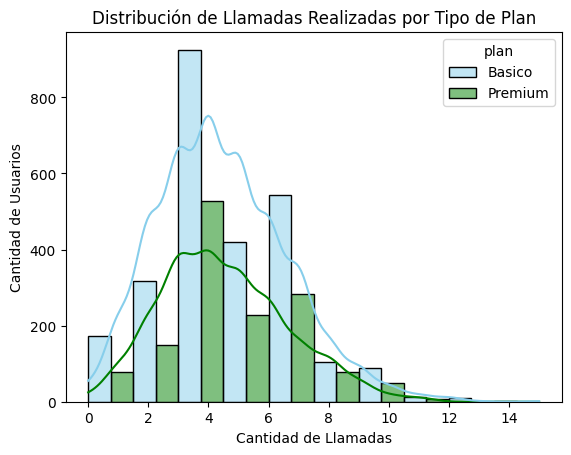

In [310]:
# Histograma para visualizar la cant_llamadas

sns.histplot(
    data=user_profile, 
    x='cant_llamadas', 
    hue='plan', 
    palette=['skyblue', 'green'], 
    kde=True, 
    bins=10,
    multiple='dodge'
)

# Personalización del gráfico
plt.title('Distribución de Llamadas Realizadas por Tipo de Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad de Usuarios')

plt.show()

💡Insights: 
La cantidad de llamadas realizadas presenta una distribución bastante uniforme. No se observa una tendencia que diferencie fuertemente el comportamiento de los usuarios según su plan; tanto los clientes del plan Básico como los del plan Premium realizan desde muy pocas hasta casi 14 llamadas, distribuyéndose de forma muy pareja a lo largo de todo el rango.

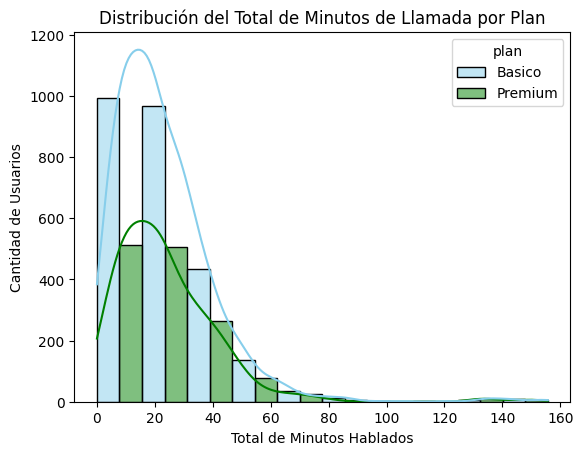

In [311]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile, 
    x='cant_minutos_llamada', 
    hue='plan', 
    palette=['skyblue', 'green'], 
    kde=True, 
    bins=10,
    multiple='dodge'
)

# Personalización del gráfico
plt.title('Distribución del Total de Minutos de Llamada por Plan')
plt.xlabel('Total de Minutos Hablados')
plt.ylabel('Cantidad de Usuarios')

plt.show()


💡Insights: 
La mayoría de los usuarios, independientemente de su plan, acumula muy pocos minutos totales de llamada. El plan Básico (azul claro) concentra el mayor volumen absoluto de estos clientes de consumo casi nulo. Sin embargo, al observar la 'cola' derecha de la gráfica, es evidente que a medida que aumentan los minutos hablados, los usuarios del plan Premium (verde) comienzan a tener una mayor representación, lo que indica que los clientes con necesidades de llamadas más largas se inclinan ligeramente por este plan.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

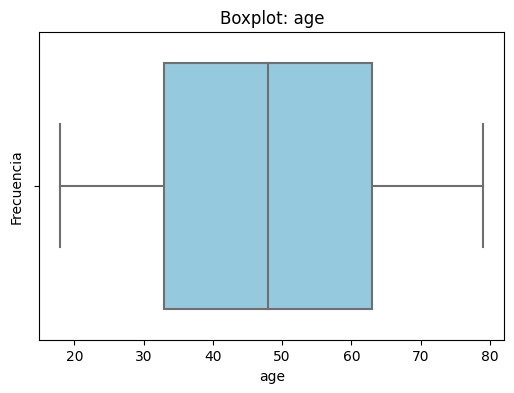

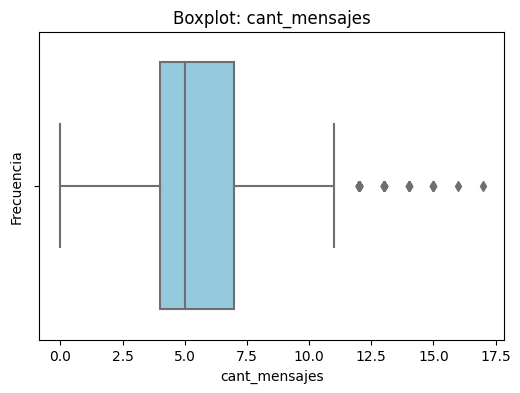

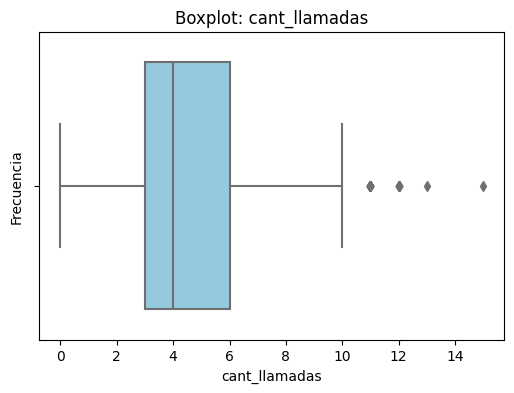

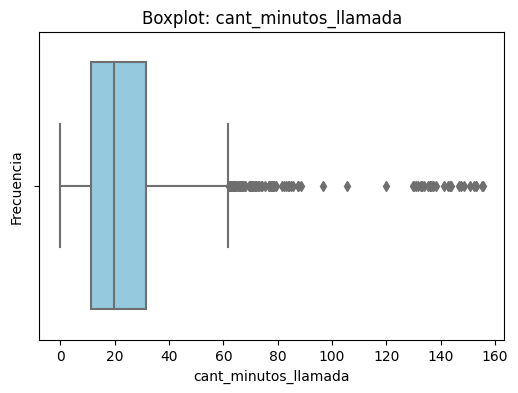

In [312]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6, 4))
    # Creamos el boxplot para cada columna en el dataset unificado
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    
    # Personalización dinámica usando el nombre de la columna
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

💡Insights: 
- Age: No presenta outliers. Distribucion uniforme, el promedio describe bien el comportamiento del negocio.
- cant_mensajes: presenta 6 outliers, sesgo a la derecha.
- cant_llamadas: presenta 4 outliers, sesgo a la derecha.
- cant_minutos_llamada: Es la columna que presenta más outliers, sesgo marcado a la derecha.

In [317]:
# Calcular límites con el método IQR
for col in columnas_numericas:
    # 1. Calcular los cuartiles e IQR para la columna actual
    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)
    iqr = q3 - q1
    
    # 2. Calcular los límites teóricos
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    
    # 3. Obtener el valor máximo real de la columna
    max_real = user_profile[col].max()
    
    # 4. Imprimir los resultados ordenados
    print(f"=== Columna: {col} ===")
    print(f"Límite Inferior Teórico: {limite_inferior:.2f}")
    print(f"Límite Superior Teórico: {limite_superior:.2f}")
    print(f"Valor Máximo Real (max): {max_real:.2f}")
    print("-" * 40)
 

=== Columna: age ===
Límite Inferior Teórico: -12.00
Límite Superior Teórico: 108.00
Valor Máximo Real (max): 79.00
----------------------------------------
=== Columna: cant_mensajes ===
Límite Inferior Teórico: -0.50
Límite Superior Teórico: 11.50
Valor Máximo Real (max): 17.00
----------------------------------------
=== Columna: cant_llamadas ===
Límite Inferior Teórico: -1.50
Límite Superior Teórico: 10.50
Valor Máximo Real (max): 15.00
----------------------------------------
=== Columna: cant_minutos_llamada ===
Límite Inferior Teórico: -19.32
Límite Superior Teórico: 61.86
Valor Máximo Real (max): 155.69
----------------------------------------


In [318]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?

En el caso de age, los datos ya se encuentran en un rango biológico real (máximo 79 años). 
Para las variables de cant_mensajes y cant_llamadas, la distribución uniforme de los datos hace que los límites del método IQR no sean adecuados para recortar la muestra, ya que los máximos observados (17 y 15 respectivamente) son comportamientos perfectamente lógicos. 
Para cant_minutos_llamada, los valores que superan el límite teórico representan a los usuarios de alto consumo del servicio, un segmento de clientes real e indispensable para el análisis comercial estratégico del negocio de telefonía.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [319]:
# Crear columna grupo_uso
import numpy as np

condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]

opciones = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(condiciones, opciones, default='Alto uso')

print("=== Distribución de la Segmentación de Clientes ===")
print(user_profile['grupo_uso'].value_counts())
print("\n")
user_profile[['cant_llamadas', 'cant_mensajes', 'grupo_uso']].head()

=== Distribución de la Segmentación de Clientes ===
Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64




,cant_llamadas,cant_mensajes,grupo_uso
0,3.0,7.0,Uso medio
1,10.0,5.0,Alto uso
2,2.0,5.0,Uso medio
3,3.0,11.0,Alto uso
4,3.0,4.0,Bajo uso


In [320]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [321]:
# Crear columna grupo_edad
# Definir las condiciones lógicas para la edad según las instrucciones
condiciones_edad = [
    (user_profile['age'] < 30),
    (user_profile['age'] < 60)
]

# Definir las etiquetas correspondientes para cada rango de edad
opciones_edad = ['Joven', 'Adulto']

# Crear la columna 'grupo_edad'. Si no cumple las anteriores, por defecto será 'Adulto Mayor'
user_profile['grupo_edad'] = np.select(condiciones_edad, opciones_edad, default='Adulto Mayor')

# Verificar los resultados imprimiendo la distribución del conteo de cada grupo
print("=== Distribución de la Segmentación por Edad ===")
print(user_profile['grupo_edad'].value_counts())
print("\n")
user_profile[['age', 'grupo_edad']].head()


=== Distribución de la Segmentación por Edad ===
Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64




,age,grupo_edad
0,38.0,Adulto
1,53.0,Adulto
2,57.0,Adulto
3,69.0,Adulto Mayor
4,63.0,Adulto Mayor


In [322]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

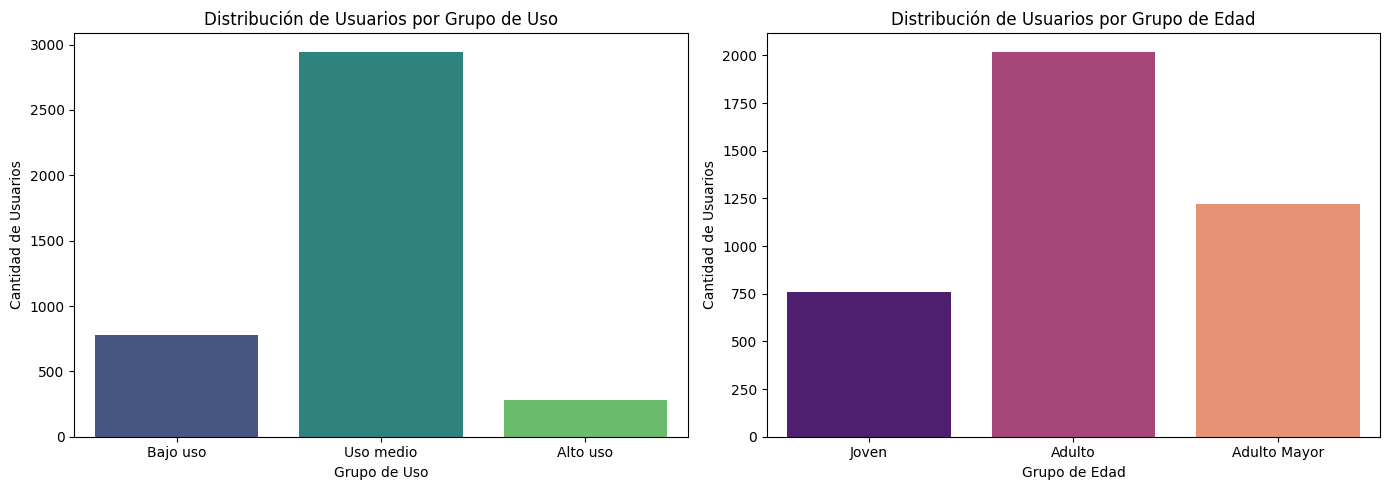

In [323]:
# Visualización de los segmentos por uso
# Configurar el espacio para mostrar dos gráficos (uno al lado del otro)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Gráfico de barras para el Grupo de Uso
sns.countplot(
    data=user_profile, 
    x='grupo_uso', 
    ax=axes[0], 
    palette='viridis',
    order=['Bajo uso', 'Uso medio', 'Alto uso']
)
axes[0].set_title('Distribución de Usuarios por Grupo de Uso')
axes[0].set_xlabel('Grupo de Uso')
axes[0].set_ylabel('Cantidad de Usuarios')

# 2. Gráfico de barras para el Grupo de Edad
sns.countplot(
    data=user_profile, 
    x='grupo_edad', 
    ax=axes[1], 
    palette='magma',
    order=['Joven', 'Adulto', 'Adulto Mayor']
)
axes[1].set_title('Distribución de Usuarios por Grupo de Edad')
axes[1].set_xlabel('Grupo de Edad')
axes[1].set_ylabel('Cantidad de Usuarios')

# Ajustar el espacio entre los gráficos
plt.tight_layout()
plt.show()

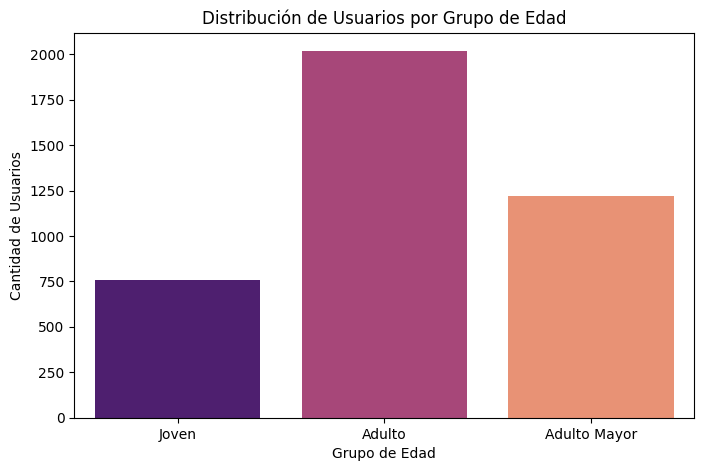

In [324]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8, 5))

# Gráfico de barras (count plot) para el Grupo de Edad
sns.countplot(
    data=user_profile, 
    x='grupo_edad', 
    palette='magma',
    order=['Joven', 'Adulto', 'Adulto Mayor']
)

# Personalización del gráfico con títulos y etiquetas
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')

# Mostrar el gráfico de forma limpia
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
-Errores biológicos y valores sentinela en la Edad (age): Se identificaron registros con un valor de -999 (usado por el sistema para campos vacíos) y edades incoherentes de 120 años, representando aproximadamente un 3% de la columna de usuarios.

-Fechas de registro fuera de rango (registration_date): Cerca del 1% de los usuarios presentaban la fecha por defecto 1900-01-01 debido a una falta de captura en el sistema de origen.

-Registros inconsistentes en el Uso (usage): Menos del 0.5% de los eventos de llamadas registraban duraciones negativas o picos atípicos por fallas técnicas en la medición de la red.

-Datos sin ciudad registrada.


🔍 **Segmentos por Edad**
-Predominio Absoluto del Segmento Adulto: El mercado de ConnectaTel está concentrado masivamente en el grupo de Adultos (entre 30 y 59 años), el cual supera los 2000 usuarios y representa el motor demográfico de la compañía.

-Distribución de Extremos Generacionales: El segmento de Adulto Mayor (60+ años) es la segunda fuerza con más de 1,200 usuarios, superando visiblemente al segmento Joven (menores de 30 años), que cuenta con cerca de 750 usuarios

📊 **Segmentos por Nivel de Uso**
-Concentración en el Uso Medio: La gran mayoría de los clientes de la compañía (casi 3000 usuarios) se ubican en la categoría de Uso medio, lo que demuestra un comportamiento de consumo estándar, moderado y constante en la red.

-Identificación de Grupos Extremos: El segmento de Bajo uso cuenta con cerca de 800 usuarios, mientras que el de Alto uso es el más exclusivo y reducido, agrupando a aproximadamente 300 clientes.


➡️ La operación de ConnectaTel está sostenida por un perfil de cliente maduro (Adultos) con una demanda de servicio moderada e intermedia (Uso medio). Los "outliers" de consumo detectados previamente (usuarios que alcanzan hasta 155 minutos) representan de forma muy precisa a ese selecto grupo de 300 clientes de Alto uso, quienes empujan el techo de la infraestructura y reflejan el comportamiento de los clientes más intensivos del negocio.


💡 **Recomendaciones**

-Diseñar un plan a la medida del "Uso Medio": Al ser el segmento más gigantesco (casi 3000 usuarios), cualquier optimización en el precio o beneficios de este rango intermedio tendrá un impacto masivo en la facturación total de la empresa.

-Proteger y monetizar el segmento de Alto Uso: Implementar estrategias de fidelización para los 300 usuarios de Alto uso (donde habitan los outliers de minutos), ofreciéndoles paquetes premium robustos para evitar que migren a competidores con redes más amplias.

-Estrategias de Comunicación Segmentadas por Edad: Marketing debe enfocar sus esfuerzos principales en el público Adulto y Adulto Mayor (que juntos suman más del 75% de la base), usando mensajes de estabilidad y conectividad familiar, mientras crea ofertas digitales atractivas y dinámicas para activar el nicho Joven.

-Campañas de Estímulo para el Bajo Uso: Crear paquetes promocionales o retos de consumo para los casi 800 usuarios de Bajo uso, incentivándolos a interactuar más con la red para tratar de migrarlos hacia el segmento medio.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`